Рябова Софья ИУ5-65Б 14 вариант, задача 2, 6 набор данных

In [2]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("Admission_Predict_Ver1.1.csv")

df.columns = [col.strip().replace(" ", "_") for col in df.columns]

print(df.columns.tolist())
print(df.head())
print(df.info())

['Serial_No.', 'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit']
   Serial_No.  GRE_Score  TOEFL_Score  University_Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance_of_Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial_No.         500 non-null    

Добавим категориальный признак для пропусков. Разобьем GRE на категории

In [38]:
def gre_to_cat(score):
    if score < 310:
        return "low"
    elif score < 330:
        return "medium"
    else:
        return "high"

In [39]:
df["GRE_Level"] = df["GRE_Score"].apply(gre_to_cat)

In [40]:
np.random.seed(42)
n = len(df)

Индексы для пропусков

In [41]:
idx_num_nan = np.random.choice(n, size=int(0.1*n), replace=False)
idx_cat_nan = np.random.choice(n, size=int(0.1*n), replace=False)

In [42]:
df.loc[idx_num_nan, "TOEFL_Score"] = np.nan
df.loc[idx_cat_nan, "GRE_Level"] = np.nan

Число пропусков после внесения NaN

In [25]:
print(df.isna().sum())

Serial No.                      0
GRE Score                       0
TOEFL Score                    40
University Rating               0
SOP                             0
LOR                             0
CGPA                            0
Research                        0
Chance of Admit                 0
GRE_Level                      40
TOEFL_Score                   400
TOEFL_Score_imputed_median    400
TOEFL_Score_imputed_mean      400
GRE_Level_imputed_mode          0
GRE_Level_imputed_unknown       0
GRE Level                      40
dtype: int64


Обработка пропусков

Количественный признак заполняем медианой, категориальный признак заполняем модой и средним

In [45]:
toefl_median = df["TOEFL_Score"].median()
toefl_mean = df["TOEFL_Score"].mean()

In [46]:
df["TOEFL_Score_imputed_median"] = df["TOEFL_Score"].fillna(toefl_median)
df["TOEFL_Score_imputed_mean"] = df["TOEFL_Score"].fillna(toefl_mean)

Категориальный признак заполняем модой и категорией "unknown"

In [48]:
gre_mode = df["GRE_Level"].mode()[0]

In [50]:
df["GRE_Level_imputed_mode"] = df["GRE_Level"].fillna(gre_mode)
df["GRE_Level_imputed_unknown"] = df["GRE_Level"].fillna("unknown")

Категориальный признак после обработки

In [52]:
print(df[["GRE_Score", "GRE_Level",
          "GRE_Level_imputed_mode",
          "GRE_Level_imputed_unknown"]].head(15))

    GRE_Score GRE_Level GRE_Level_imputed_mode GRE_Level_imputed_unknown
0         337      high                   high                      high
1         324    medium                 medium                    medium
2         316    medium                 medium                    medium
3         322    medium                 medium                    medium
4         314    medium                 medium                    medium
5         330      high                   high                      high
6         321    medium                 medium                    medium
7         308       low                    low                       low
8         302       low                    low                       low
9         323    medium                 medium                    medium
10        325    medium                 medium                    medium
11        327    medium                 medium                    medium
12        328    medium                 medium     

Проверка результата заполнения количественного признака

Количественный признак после обработки пропусков

In [53]:
print(df[["TOEFL_Score",
          "TOEFL_Score_imputed_median",
          "TOEFL_Score_imputed_mean"]].head(15))

    TOEFL_Score  TOEFL_Score_imputed_median  TOEFL_Score_imputed_mean
0           NaN                       107.0                107.184444
1         107.0                       107.0                107.000000
2           NaN                       107.0                107.184444
3         110.0                       110.0                110.000000
4         103.0                       103.0                103.000000
5         115.0                       115.0                115.000000
6         109.0                       109.0                109.000000
7         101.0                       101.0                101.000000
8         102.0                       102.0                102.000000
9           NaN                       107.0                107.184444
10        106.0                       106.0                106.000000
11          NaN                       107.0                107.184444
12        112.0                       112.0                112.000000
13        109.0     

Выбор признаков для построения моделей

Целевая переменная - Chance of Admit

In [33]:
target_col = "Chance_of_Admit"

Для модели используем:
- числовые признаки без пропусков/ с заполнением медианой
- категориальный признак (GRE_Level_imputed_mode) или unknown

In [57]:
features_base = [
    "GRE_Score",
    "TOEFL_Score_imputed_median",
    "University_Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
]

Добавляем обработанный категориальный признак

In [58]:
df_model = df[features_base + ["GRE_Level_imputed_mode", target_col]].copy()

One-hot кодирование категориального признака

In [59]:
df_model = pd.get_dummies(df_model,
                          columns=["GRE_Level_imputed_mode"],
                          drop_first=True)

In [60]:
print(df_model.head())
print(df_model.isna().sum())

   GRE_Score  TOEFL_Score_imputed_median  University_Rating  SOP  LOR  CGPA  \
0        337                       107.0                  4  4.5  4.5  9.65   
1        324                       107.0                  4  4.0  4.5  8.87   
2        316                       107.0                  3  3.0  3.5  8.00   
3        322                       110.0                  3  3.5  2.5  8.67   
4        314                       103.0                  2  2.0  3.0  8.21   

   Research  Chance_of_Admit  GRE_Level_imputed_mode_low  \
0         1             0.92                       False   
1         1             0.76                       False   
2         1             0.72                       False   
3         1             0.80                       False   
4         0             0.65                       False   

   GRE_Level_imputed_mode_medium  
0                          False  
1                           True  
2                           True  
3                       

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

Числовые признаки + целевая переменная

In [62]:
pairplot_cols = [
    "GRE_Score",
    "TOEFL_Score_imputed_median",
    "University_Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance_of_Admit"
]

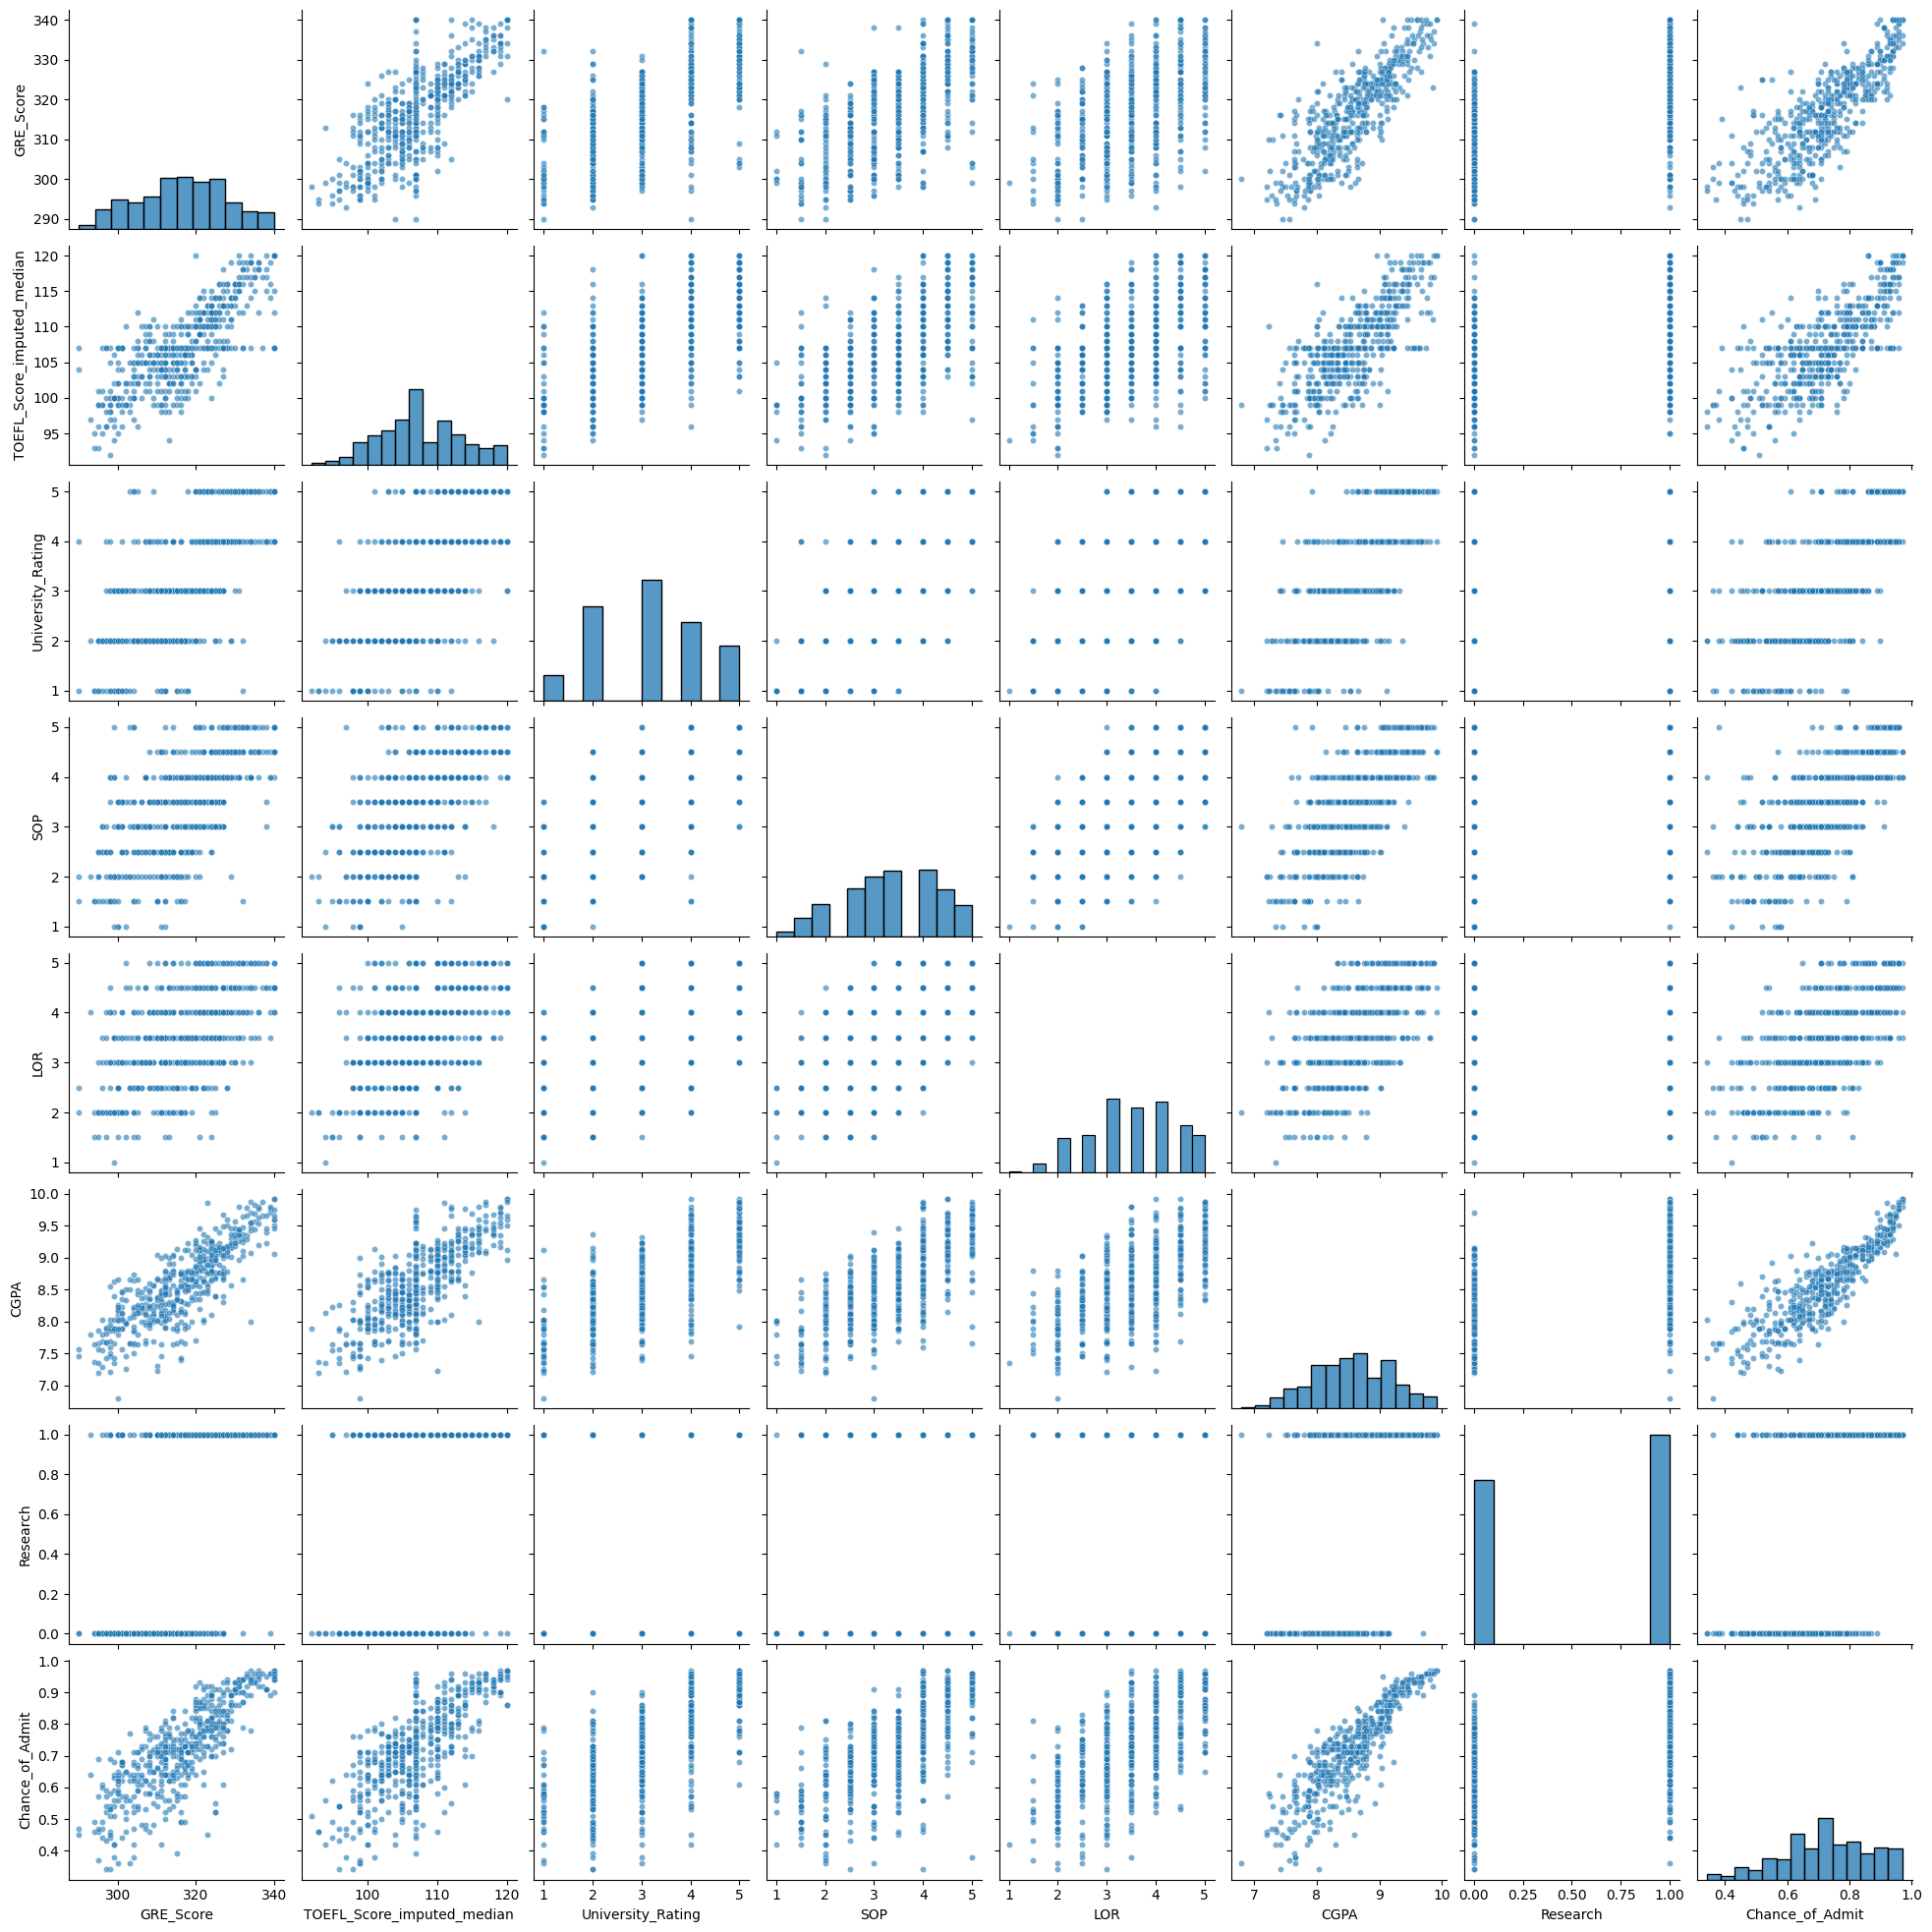

In [63]:
sns.pairplot(
    df_model[pairplot_cols],
    diag_kind="hist",     #на диагонали – гистограммы распределений
    plot_kws={"alpha": 0.6, "s": 20}  #прозрачность и размер точек
)

Какие способы обработки использованы:
- Для количественного признака TOEFL_Score:

Заполнение медианой, средним значением (альтернатива)

- Для категориального признака GRE_Level:

Заполнение модой, категорией "unknown" (позволяет явно выделять объекты с отсутствующим значением)

Какие признаки использовать для дальнейшего построения моделей и почему:

- Для обучения модели регрессии вероятности поступления (Chance_of_Admit) используются все информативные числовые признаки датасета:

GRE_Score, TOEFL_Score_imputed_median, University_Rating, SOP, LOR_, CGPA, Research, так как они отражают академические показатели и опыт абитуриента и по постановке задачи влияют на вероятность поступления

- Для категориального признака:

Используется GRE_Level_imputed_mode, закодированный методом one‑hot, чтобы модель могла учитывать интервальные уровни GRE как отдельные категории, не внося искусственный порядок и масштабы

